In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 

# choose one of the following implementations of EMT:
# included in ase
# from ase.calculators.emt import EMT
# faster performance

from ase.calculators.tip4p import TIP3P
from ase import units
from ase.io import read

from ase.io.trajectory import Trajectory

from ase.md.velocitydistribution import (
    MaxwellBoltzmannDistribution,
    Stationary,
    ZeroRotation,
)
from ase.md.verlet import VelocityVerlet
from ase.optimize import QuasiNewton
from ase.visualize.plot import plot_atoms

import torch
import torch.nn as nn 

### Feeding extended .xyz data into model.

Currently, the models are fed node, edge, and triplet features. A method must be devised to reengineer the extended xyz data to feed to the network.

In [ ]:
with open('water_test.xyz', 'r') as xyz_file:
    energy_line = xyz_file.readlines()[1]
    print(energy_line)
    e_index = energy_line.index('=')
    print(e_index)

    lines = xyz_file.readlines()[2:]


# extract atomic symbols 
elements = [] # ??? check what structure the elements are passed as in the model 
for line in lines:
    elements.append(line.split()[0])

# extract total energy 
energy_line.find('energy=')

# extract atomic coordinates # ??? check what form the coordinates are stored in 
atomic_coordiates = np.array([line.split()[1:4] for line in lines], dtype=float)

# extract atomic forces 
atomic_forces = np.array([line.split()[7:10] for line in lines], dtype=float)



Lattice="18.574632553761653 0.0 0.0 0.0 18.574632553761653 0.0 0.0 0.0 18.574632553761653" Properties=species:S:1:pos:R:3:momenta:R:3:forces:R:3 energy=-33989.524696517 pbc="T T T"

7


Creating custom calculator 

Models will be trained using extended xyz trajectory files. 

In [ ]:
#!/usr/bin/env amspython

from ase.calculators.calculator import Calculator, all_changes
import numpy as np

# ML classifier 
class WedgeMLP(nn.Module):
    """
    forward_energy: scalar E_total.
    energy_and_forces: (E_total, forces) with forces = -∇E w.r.t. pos_t.
    """
    def __init__(self):
        super().__init__()

        self.node_net = nn.Sequential(
            nn.Linear(1, 64), nn.LeakyReLU(), 
            nn.Linear(64,64),nn.LeakyReLU(), 
            nn.Linear(64,4), nn.LeakyReLU(),
             nn.Linear(4,1)
        )
        self.edge_net = nn.Sequential(
            nn.Linear(2, 64), nn.LeakyReLU(), 
            nn.Linear(64,64), nn.LeakyReLU(), 
            nn.Linear(64,4),nn.LeakyReLU(),
            nn.Linear(4,1)
        )
        self.triplet_net = nn.Sequential(
            nn.Linear(1, 64), nn.LeakyReLU(), 
            nn.Linear(64,64),nn.LeakyReLU(), 
            nn.Linear(64,4), nn.LeakyReLU(),
             nn.Linear(4,1)
        )



        self.to(device)

    def forward_energy(self, node_feats, edge_feats, triplets):
        node_E = self.node_net(node_feats).sum()
        edge_E = self.edge_net(edge_feats).sum()
        if len(triplets) > 0:
            edge_E = edge_E + self.triplet_net(triplets).sum()
        return node_E + edge_E

    def energy_per_atom(self, node_feats, edge_feats, triplets):
        total_E = self.forward_energy(node_feats, edge_feats, triplets)
        N = node_feats.size(0)
        return total_E / N

    def energy_and_forces(self, node_feats, edge_feats, triplets, pos_t):
        """
        pos_t: (N, 3), requires_grad=True.
        Returns:
            total_E: scalar
            forces: (N, 3) = -∂E/∂pos_t
        """
        with torch.enable_grad():
            total_E = self.forward_energy(node_feats, edge_feats, triplets)

            # Explicitly require_grad on pos_t if it ever got detached
            if pos_t.grad is not None:
                pos_t.grad.zero_()

            # Compute gradient
            grad_outputs = torch.ones_like(total_E)
            grad_list = torch.autograd.grad(
                outputs=total_E,
                inputs=pos_t,
                grad_outputs=grad_outputs,
                create_graph=False,
                allow_unused=True
            )

            if grad_list[0] is None:
                # Something is wrong; fall back to zeros
                forces = torch.zeros_like(pos_t)
            else:
                forces = -grad_list[0]   # F = -∇E

        return total_E, forces
    
    def save(self, filename='model_2.pt'):

        torch.save(self.state_dict(), filename)
        print(f"Model saved to {filename}")
        
class ModelCalculator(Calculator):
    implemented_properties = ["energy", "forces"]

    def calculate(self, atoms=None, properties=["energy"], system_changes=all_changes):
        super().calculate(atoms, properties, system_changes)
        self.results = dict()
        if atoms is not None:
            energy_per_atom = self.parameters.get("energy_per_atom", 0.0)
            self.results = {
                "energy": energy_per_atom * len(atoms),
                "forces": np.zeros((len(atoms), 3)),
            }


def get_calculator(energy_per_atom: float = 0.0):
    """energy_per_atom: float (eV). Always returns zero forces."""
    return ZeroCalculator(energy_per_atom=energy_per_atom)


def example():
    """Simple example for a water molecule.

    Note: this is just an example of the ASE calculator. This section
    has no effect when running through AMS.
    """
    from ase.build import molecule

    atoms = molecule("H2O")
    atoms.calc = get_calculator(energy_per_atom=1.0)

    energy = atoms.get_potential_energy()
    forces = atoms.get_forces()

    print(f"Energy of water molecule: {energy:.3f} eV")
    print(f"Forces (eV/ang): {forces}")


if __name__ == "__main__":
    example()

running a NVE simulation of equilibrated water 
Energy per atom: Epot =40.449eV  Ekin = 16.670eV (T=298.522K) Etot = 57.118eV
Energy per atom: Epot =40.204eV  Ekin = 16.914eV (T=302.906K) Etot = 57.119eV
Energy per atom: Epot =39.470eV  Ekin = 17.650eV (T=316.086K) Etot = 57.120eV
Energy per atom: Epot =38.115eV  Ekin = 19.008eV (T=340.401K) Etot = 57.123eV
Energy per atom: Epot =35.933eV  Ekin = 21.193eV (T=379.530K) Etot = 57.126eV
Energy per atom: Epot =32.670eV  Ekin = 24.457eV (T=437.989K) Etot = 57.128eV
Energy per atom: Epot =28.087eV  Ekin = 29.040eV (T=520.050K) Etot = 57.126eV
Energy per atom: Epot =22.050eV  Ekin = 35.070eV (T=628.048K) Etot = 57.120eV
Energy per atom: Epot =14.639eV  Ekin = 42.469eV (T=760.551K) Etot = 57.108eV
Energy per atom: Epot = 6.197eV  Ekin = 50.894eV (T=911.424K) Etot = 57.091eV
Energy per atom: Epot =-2.709eV  Ekin = 59.780eV (T=1070.558K) Etot = 57.071eV
Energy per atom: Epot =-11.411eV  Ekin = 68.463eV (T=1226.052K) Etot = 57.052eV
Energy per at

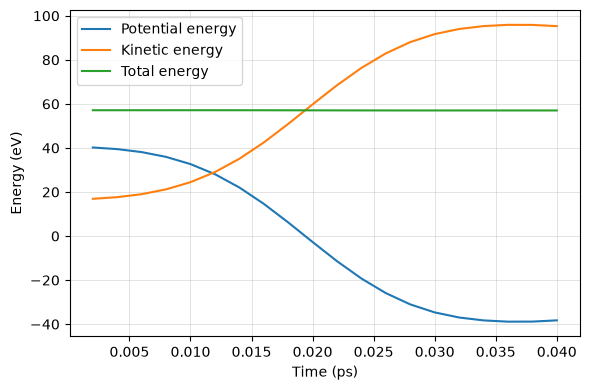

In [ ]:


# Describe the interatomic interactions with the Effective Medium Theory (EMT)
# custom calculator here 
water_molecules.calc = TIP3P()

# Set the initial velocities corresponding to T=300K from Maxwell Boltzmann
# Distribution
MaxwellBoltzmannDistribution(water_molecules, temperature_K=300)


timestep_fs = 1
dyn = VelocityVerlet(water_molecules, timestep_fs * units.fs)  # 1 fs time step.

def printenergy(a):
    """
    Function to print the thermodynamical properties i.e potential energy,
    kinetic energy and total energy
    """
    epot = a.get_potential_energy()
    ekin = a.get_kinetic_energy()
    temp = a.get_temperature()
    print(
        f'Energy per atom: Epot ={epot:6.3f}eV  Ekin = {ekin:.3f}eV '
        f'(T={temp:.3f}K) Etot = {epot + ekin:.3f}eV'
    )

# Now run the dynamics
print('running a NVE simulation of equilibrated water ')
printenergy(water_molecules)
# init lists to for energy vs time data
time_ps, epot, ekin = [], [], []
mdind = 0
steps_per_block = 2
for i in range(20):
    dyn.run(steps_per_block)
    mdind += steps_per_block
    printenergy(water_molecules)
    # save the energies of the current MD step
    time_ps.append(mdind * timestep_fs / 1000.0)
    epot.append(water_molecules.get_potential_energy())
    ekin.append(water_molecules.get_kinetic_energy())

etot = np.array(epot) + np.array(ekin)

# Plot energies vs time
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(time_ps, epot, label='Potential energy')
ax.plot(time_ps, ekin, label='Kinetic energy')
ax.plot(time_ps, etot, label='Total energy')
ax.set_xlabel('Time (ps)')
ax.set_ylabel('Energy (eV)')
ax.legend(loc='best')
ax.grid(True, linewidth=0.5, alpha=0.5)
plt.tight_layout()

plt.savefig('waterMD.png')
plt.show()


Creating custom calculator

In [7]:
from ase.calculators.calculator import Calculator, all_changes 

class MLPCalculator(Calculator):
    implemented_properties = ['energy', 'forces']

    def calculate(self, atoms=None, properties=['energy','forces'], system_changes=all_changes):
        super().calculate(atoms, properties, system_changes)
        self.results = dict()
        if atoms is not None:
            energy_per_atom = self.parameters.get('energy_per_atom', 0.0)
            self.results = {
                'energy': energy_per_atom * len(atoms),
                'forces': np.zeros((len(atoms), 3)),
            }

def get_calculator(energy_per_atom: float = 0.0):
    return MLPCalculator(energy_per_atom=energy_per_atom)

def example():
    from ase.build import molecule

    atoms = molecule("H2O")
    atoms.calc = get_calculator(energy_per_atom=1.0)

    energy = atoms.get_potential_energy()
    forces = atoms.get_forces()

    print(f"Energy of water molecule: {energy:.3f} eV")
    print(f"Forces (eV/ang): {forces}")
